<a href="https://colab.research.google.com/github/AndresMontesDeOca/AnalisisDatos2/blob/main/Entregas/Actividad3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
! pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# 1. Cargar el dataset de UCI
communities_and_crime = fetch_ucirepo(id=183)
X = communities_and_crime.data.features
y = communities_and_crime.data.targets

# 2. Combinar X e y en un solo DataFrame
data = pd.concat([X, y], axis=1)

# Reemplazar los '?' por NaN reales de numpy
data = data.replace('?', np.nan)

# Mostrar el resumen del DataFrame limpio
print(data.info())
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(100), int64(2), object(26)
memory usage: 1.9+ MB
None


,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


<Figure size 1000x600 with 0 Axes>

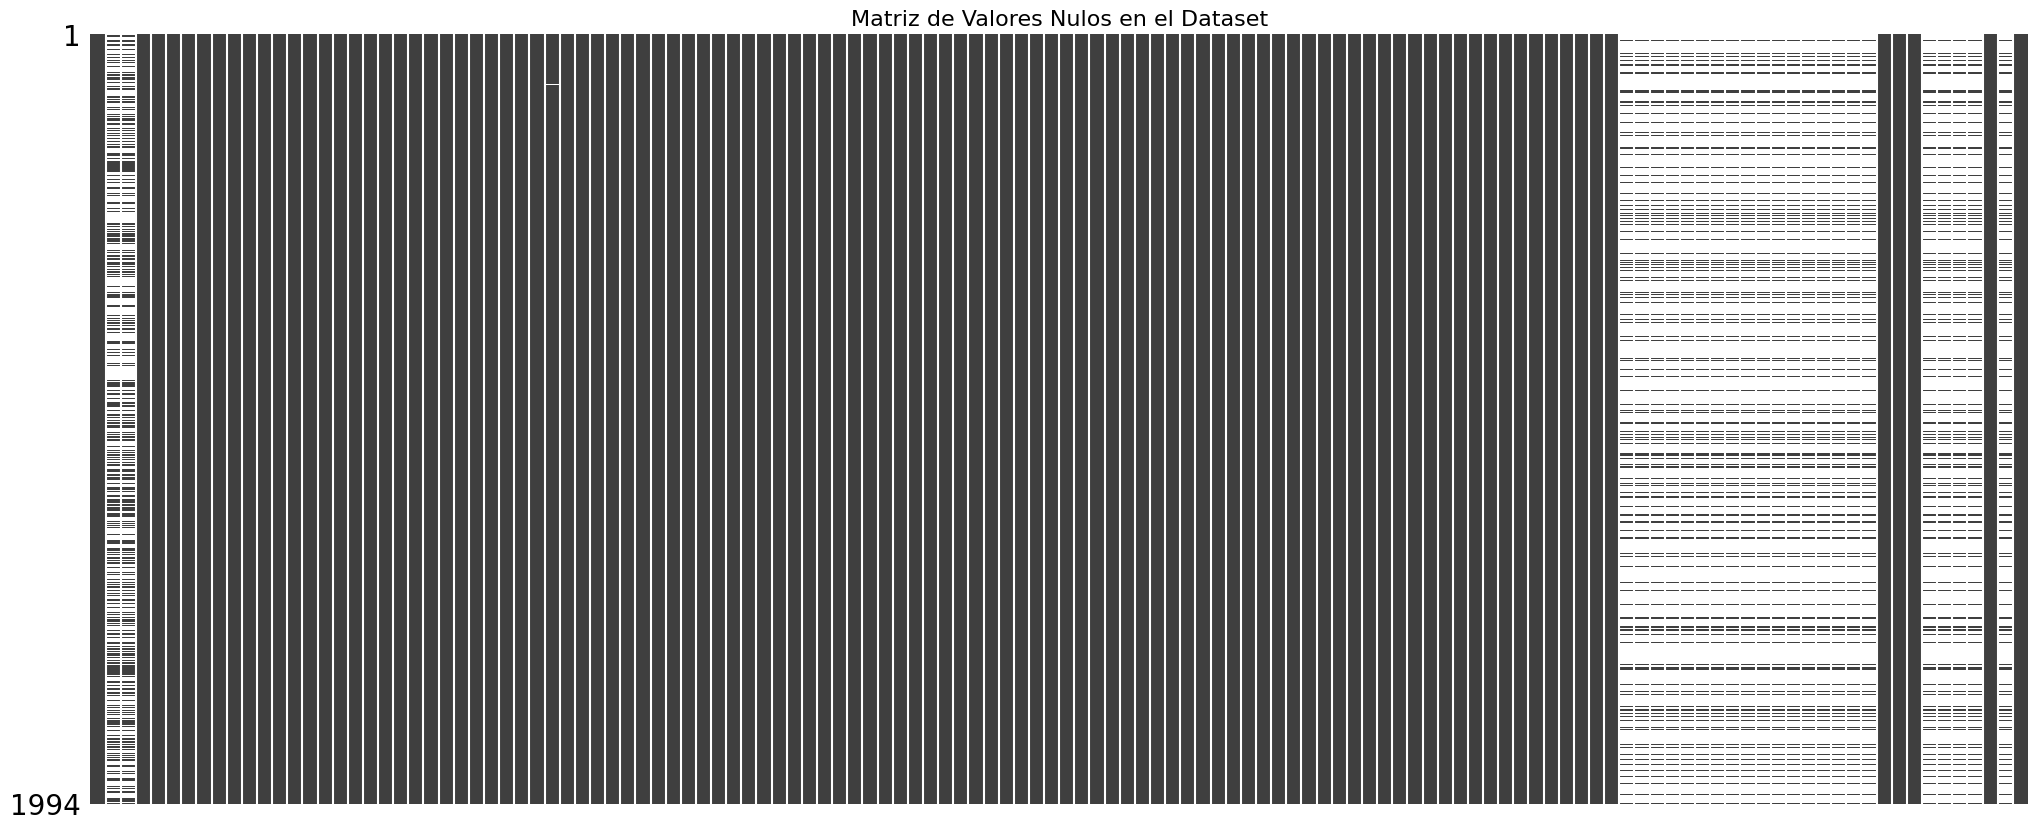

In [14]:
import missingno as msno
import matplotlib.pyplot as plt

# Visualizar la matriz de valores nulos
plt.figure(figsize=(10, 6))
msno.matrix(data, sparkline=False)
plt.title("Matriz de Valores Nulos en el Dataset", fontsize=16)
plt.show()

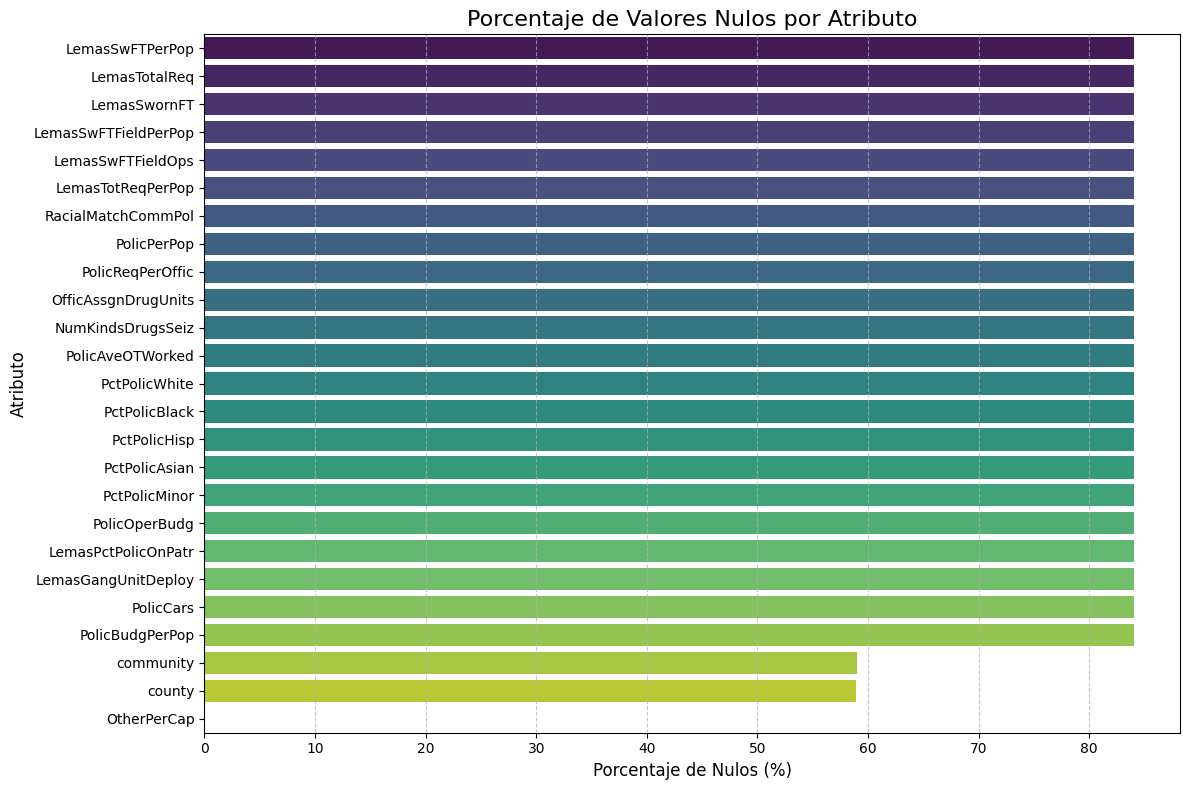

In [15]:
import seaborn as sns

# Calcular el porcentaje de nulos
null_percentages = (data.isnull().sum() / len(data)) * 100

# Filtrar solo las columnas con nulos y ordenarlas
null_cols = null_percentages[null_percentages > 0].sort_values(ascending=False).reset_index()
null_cols.columns = ['Atributo', 'Porcentaje_Nulos']

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x='Porcentaje_Nulos', y='Atributo', data=null_cols, palette='viridis', hue='Atributo', legend=False)

# Configurar etiquetas y títulos
plt.title('Porcentaje de Valores Nulos por Atributo', fontsize=16)
plt.xlabel('Porcentaje de Nulos (%)', fontsize=12)
plt.ylabel('Atributo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [16]:
# Contar valores nulos específicos para state, county y community
nulos_geograficos = data[['state', 'county', 'community']].isnull().sum()

for col, nulos in nulos_geograficos.items():
    total = len(data)
    pct = (nulos / total) * 100
    print(f"Columna '{col}': {nulos} valores nulos de {total} ({pct:.2f}%)")

Columna 'state': 0 valores nulos de 1994 (0.00%)
Columna 'county': 1174 valores nulos de 1994 (58.88%)
Columna 'community': 1177 valores nulos de 1994 (59.03%)


### Exploración de la Variable Objetivo: `ViolentCrimesPerPop`

In [17]:
# 1. Estadísticas descriptivas de la variable objetivo
print("Estadísticas Descriptivas de 'ViolentCrimesPerPop':")
display(data['ViolentCrimesPerPop'].describe())

# Verificar si hay valores nulos en el target
nulos_target = data['ViolentCrimesPerPop'].isnull().sum()
print(f"\nValores nulos en la variable objetivo: {nulos_target}")

Estadísticas Descriptivas de 'ViolentCrimesPerPop':


,ViolentCrimesPerPop
count,1994.000000
mean,0.237979
std,0.232985
min,0.000000
25%,0.070000
50%,0.150000
75%,0.330000
max,1.000000



Valores nulos en la variable objetivo: 0


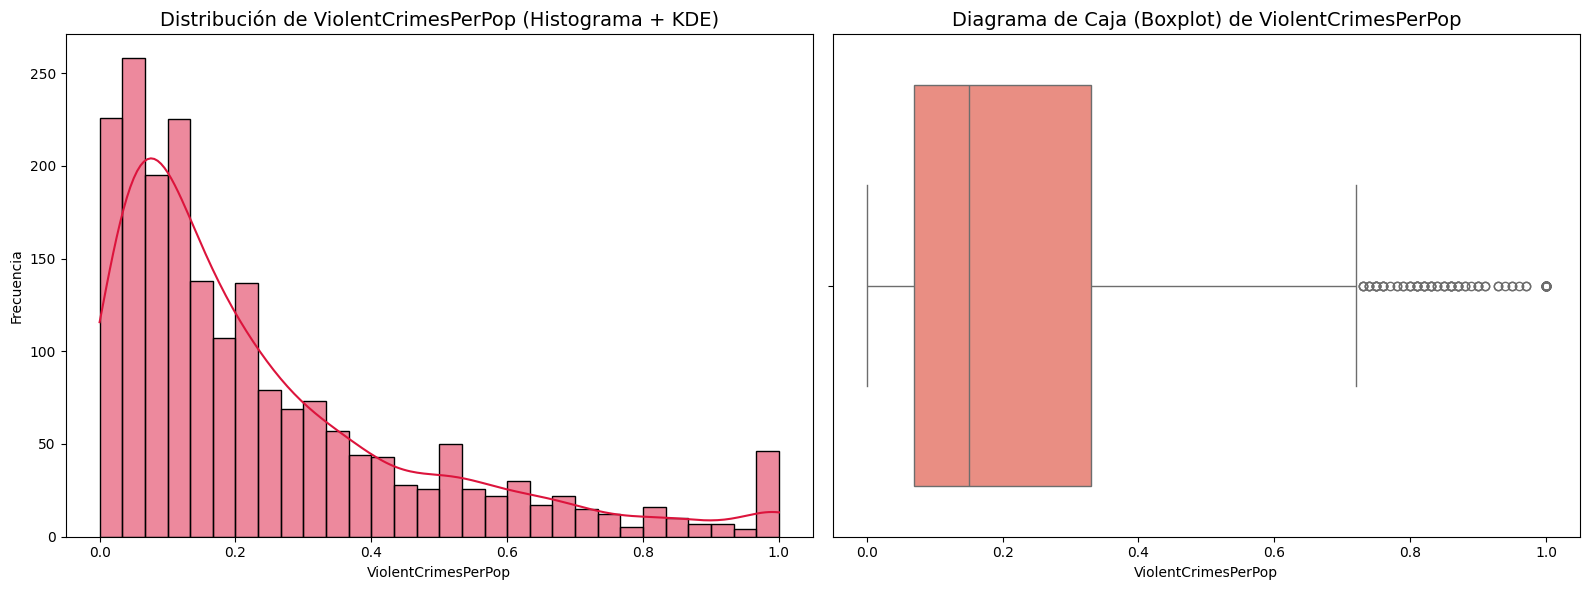

In [18]:
# 2. Visualización de la distribución del Target
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma con KDE
sns.histplot(data['ViolentCrimesPerPop'], kde=True, ax=axes[0], color='crimson', bins=30)
axes[0].set_title('Distribución de ViolentCrimesPerPop (Histograma + KDE)', fontsize=14)
axes[0].set_xlabel('ViolentCrimesPerPop')
axes[0].set_ylabel('Frecuencia')

# Boxplot para ver outliers y cuartiles
sns.boxplot(x=data['ViolentCrimesPerPop'], ax=axes[1], color='salmon')
axes[1].set_title('Diagrama de Caja (Boxplot) de ViolentCrimesPerPop', fontsize=14)
axes[1].set_xlabel('ViolentCrimesPerPop')

plt.tight_layout()
plt.show()

### Transformación a Problema de Clasificación Binaria
Definimos el umbral en **0.72** para identificar las comunidades con alta tasa de criminalidad violenta.

Distribución de la nueva variable objetivo 'HighCrime':
Clase 0: 1884 comunidades (94.48%)
Clase 1: 110 comunidades (5.52%)


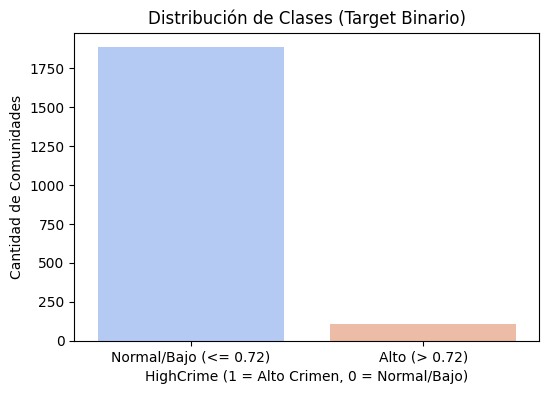

In [19]:
# Crear la nueva variable objetivo binaria
umbral = 0.72
data['HighCrime'] = (data['ViolentCrimesPerPop'] > umbral).astype(int)

# Calcular la distribución de las clases
counts = data['HighCrime'].value_counts()
percentages = data['HighCrime'].value_counts(normalize=True) * 100

print("Distribución de la nueva variable objetivo 'HighCrime':")
for val, count in counts.items():
    print(f"Clase {val}: {count} comunidades ({percentages[val]:.2f}%)")

# Graficar el balance de clases
plt.figure(figsize=(6, 4))
sns.countplot(x='HighCrime', data=data, palette='coolwarm', hue='HighCrime', legend=False)
plt.title('Distribución de Clases (Target Binario)')
plt.xlabel('HighCrime (1 = Alto Crimen, 0 = Normal/Bajo)')
plt.ylabel('Cantidad de Comunidades')
plt.xticks([0, 1], ['Normal/Bajo (<= 0.72)', 'Alto (> 0.72)'])
plt.show()

### Eliminación de la Variable Target Continua
Eliminamos `ViolentCrimesPerPop` para quedarnos únicamente con nuestro target binario `HighCrime`.

In [20]:
# Eliminar la columna del target continuo
if 'ViolentCrimesPerPop' in data.columns:
    data = data.drop(columns=['ViolentCrimesPerPop'])
    print("La columna 'ViolentCrimesPerPop' ha sido eliminada con éxito.")
else:
    print("La columna 'ViolentCrimesPerPop' no se encuentra en el DataFrame.")

# Verificar las columnas actuales
print(f"Dimensiones actuales del dataset: {data.shape}")

La columna 'ViolentCrimesPerPop' ha sido eliminada con éxito.
Dimensiones actuales del dataset: (1994, 128)
